---
title: "Patching code automation"
format: 
  html:
    toc: true
    toc-title: Contents
    self-contained: true
    toc-depth: 4
    number-sections: true
jupyter: python3
---

This code relies on the slice images and masks being in a folder called `testing_slices/`

Inside that folder, create a folder called `patch_outputs/` for the patches to be exported into

## Setup

In [123]:
import numpy as np
import cv2
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid
from matplotlib import colors
import pandas as pd
import csv

In [124]:
smoothing_size = 1 # make 100
extension_factor = 1.1; 
step_size = 2;
max_width = 2048
overlap_threshold = 0.3
weight_epithelium_coverage = 0.8
weight_background_pixels = 0.2

## Read in testing folder

In [125]:
import os
image_folder = './testing_slices'
image_files = [f for f in os.listdir(image_folder) if f.startswith('h&e')]

## Patching code function

In [126]:
# Function to draw patches
def draw_patches(image, patch_list, color = [255,0,0], thickness = 20):
    patches_on_slice = image.copy()
    for contour_patches in patch_list:
        for patch in contour_patches:
            points = patch.astype(np.int32)
            cv2.polylines(patches_on_slice, [points], isClosed = True, color = color, thickness = thickness)        
    return patches_on_slice

# Function to calculate patch overlap
def patch_overlap(square1,square2):

    square1 = Polygon(square1)
    square2 = Polygon(square2)

    if not square1.intersects(square2):
        return 0
    
    intersection_area = square1.intersection(square2).area
    smallest_area = min(square1.area,square2.area)
    return intersection_area/smallest_area

# Read data and get contours
def get_contours(mask_name, slice_details):

    tissue_slice = cv2.cvtColor(cv2.imread(slice_details), cv2.COLOR_BGR2RGB)
    epithelium_mask = cv2.cvtColor(cv2.imread(mask_name), cv2.COLOR_BGR2RGB)
    epithelium_mask_gray = cv2.cvtColor(epithelium_mask, cv2.COLOR_RGB2GRAY)
    Otsu_threshold, epithelium_mask_2D = cv2.threshold(epithelium_mask_gray, 0, 255, 
                            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Getting contours
    contours, hierarchy = cv2.findContours(epithelium_mask_2D, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Getting tangents and normals on contour points
    all_normals=[]
    all_tangents = []

    for contour in contours:

        contour_points = contour.reshape(-1,2)
        num_contour_points = len(contour_points)
        tangents = np.zeros_like(contour_points, dtype = float)

        for i in range(num_contour_points):
            
            prev_idx = (i - smoothing_size) % num_contour_points 
            
            next_idx = (i + smoothing_size) % num_contour_points 
            
            tangent = contour_points[next_idx] - contour_points[prev_idx]
            
            tangent = tangent / (np.linalg.norm(tangent) + 1e-8)
            tangents[i] = tangent            

        normals = np.zeros_like(tangents)
        normals[:,0] = -tangents[:,1]
        normals[:,1] = tangents[:,0]
        
        all_normals.append(normals)
        all_tangents.append(tangents)
    
    return all_normals, all_tangents, contours, epithelium_mask_2D, tissue_slice

# Get patch corners
def patch_corners(all_normals, all_tangents, contours, epithelium_mask_2D):
    
    all_patches = []
    all_patch_lengths = []
    height, width = epithelium_mask_2D.shape

    for c in range(len(contours)):
        contour_points = contours[c].reshape(-1, 2)
        contour_normals = all_normals[c]
        contour_tangents = all_tangents[c]
        contour_patch_lengths = []
        squares = []
        
        for i, point in enumerate(contour_points):
            point = point.astype(int)

            steps = np.arange(0, max_width, step_size)[:, None]
            normal_points = np.clip(point - steps * contour_normals[i], 0, [width - 1, height - 1]).astype(int)

            pixel_values = epithelium_mask_2D[normal_points[:, 1], normal_points[:, 0]]

            stop = np.where(pixel_values == 0)[0]

            epithelium_width = stop[0] * step_size if stop.size > 0 else max_width

            patch_length = int(epithelium_width * extension_factor)
            half_patch_length = patch_length // 2 

            corners = np.array([
                point + (contour_tangents[i] * half_patch_length),
                point - (contour_tangents[i] * half_patch_length),
                point - (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length),
                point + (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length)
            ])
            squares.append(corners)
            contour_patch_lengths.append(patch_length)
        all_patches.append(squares)
        all_patch_lengths.append(contour_patch_lengths)

    return all_patches, all_patch_lengths

# Remove highly overlapping contours
def remove_overlap(tissue_slice, contours, all_patches, all_patch_lengths):

    all_selected_patches = []
    all_selected_patch_lengths = []

    for c in range(len(contours)):
        contour_points = contours[c].reshape(-1, 2)
        
        selected_patches = []
        selected_patch_lengths = []
        for i, point in enumerate(contour_points):
            current_patch = all_patches[c][i]
            current_patch_length = all_patch_lengths[c][i]
            if not any(patch_overlap(current_patch, ith_selected_patch) > overlap_threshold \
                    for ith_selected_patch in selected_patches):
                selected_patches.append(current_patch)
                selected_patch_lengths.append(current_patch_length)
        all_selected_patches.append(selected_patches)
        all_selected_patch_lengths.append(selected_patch_lengths)

    selected_patches_on_slice = draw_patches(tissue_slice, all_selected_patches)
    return all_selected_patches, all_selected_patch_lengths, selected_patches_on_slice

# Export patched slice
def export_patched_slice(patched_slice_name, selected_patches_on_slice):

    output_folder = 'testing_slices/patch_outputs'
    output_path = os.path.join(output_folder, patched_slice_name)
    cv2.imwrite(output_path, cv2.cvtColor(selected_patches_on_slice, cv2.COLOR_RGB2BGR))

In [127]:
# Calculate performance metrics
def calculate_metrics(epithelium_mask_2D, all_selected_patches):

    total_epithelium_pixels = (epithelium_mask_2D > 0).sum()
    patch_mask = np.zeros_like(epithelium_mask_2D, dtype=np.uint8)

    #For all patches in all contours, use them to create a mask
    for contour_patches in all_selected_patches:
        for patch in contour_patches:
            patch = np.array(patch,dtype = np.int32).reshape(-1, 1, 2)
            cv2.fillPoly(patch_mask, [patch], 255)

    number_of_patch_mask_pixels = np.count_nonzero(patch_mask > 0)

    covered_epithelium_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D > 0))
    covered_background_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D == 0))

    total_epithelium_coverage = (covered_epithelium_pixels / total_epithelium_pixels*100)
    background_pixel_percent = (covered_background_pixels / number_of_patch_mask_pixels*100)
    score = weight_epithelium_coverage*total_epithelium_coverage + weight_background_pixels*(100 - background_pixel_percent)

    # Exporting performance metrics and parameter values
    metrics = pd.DataFrame({'Metric':['total_epithelium_coverage', 'background_pixel_percent',
                        'score', 'smoothing_size', 'extension_factor', 'step_size',
                        'max_width', 'overlap_threshold'], 
                'Value':[total_epithelium_coverage, background_pixel_percent, score, 
                        smoothing_size, extension_factor, step_size, max_width, overlap_threshold]})

    return metrics

In [128]:
# Exporting patch lengths
def export_patch_length(patch_length_filename, all_selected_patch_lengths):

    max_length = max(len(contour_patch_lengths) for contour_patch_lengths in all_selected_patch_lengths)

    padded_list = [contour_patch_lengths + [''] * (max_length - len(contour_patch_lengths)) \
                for contour_patch_lengths in all_selected_patch_lengths]

    transposed_list = list(map(list, zip(*padded_list)))

    patch_length_filename = str.replace(patch_length_filename, './testing_slices/', '')

    with open('patch_outputs/' + patch_length_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerows(transposed_list)

# Display patches on slice
def display_patches(selected_patches_on_slice):
    plt.imshow(selected_patches_on_slice)

In [129]:
# Find edges
def find_edges(all_selected_patches):
    all_points = np.vstack(all_selected_patches[0])

    edges = {'min_x': np.min(all_points[:, 0]),
             'max_x': np.max(all_points[:, 0]),
             'min_y': np.min(all_points[:, 1]),
             'max_y': np.max(all_points[:, 1])}

    return edges

In [130]:
# add padding
import math 

def add_padding(image, edges):
    
    height, width, channels = image.shape

    if edges['min_x'] < 0:
        left = math.ceil(np.abs(edges['min_x']))
    else: left = 0

    if edges['max_x'] > width:
        right = math.ceil(edges['max_x'] - width)
    else: right = 0

    if edges['min_y'] < 0:
        top = math.ceil(np.abs(edges['min_y']))
    else: top = 0

    if edges['max_y'] > height:
        bottom = math.ceil(edges['max_y'] - height)
    else: bottom = 0

    new_width = width + right + left
    new_height = height + top + bottom

    padded_image = np.ones((new_height, new_width, channels), dtype=image.dtype) *128

    # Insert the original image into the array of updated dimensions
    padded_image[top:top + height, left:left + width] = image

    # Display the images side by side
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    axes[1].imshow(padded_image)
    axes[1].set_title("Padded Image")
    axes[1].axis("off")
    plt.show()


    return padded_image, right, left, top, bottom

In [131]:
# Shift patches by padding amount
def shift_patches(padded_image, all_selected_patches, left, top):

    all_points = np.vstack(all_selected_patches[0])

    shift_x = left
    shift_y = top
    shift_array = np.array([shift_x, shift_y])
    shifted_points = all_points + shift_array
        
    shifted_points = np.split(shifted_points, len(shifted_points) // 4)
    shifted_points = [shifted_points]   

    shifted_patches_on_slice = draw_patches(padded_image, shifted_points)
    return shifted_patches_on_slice, shifted_points

In [132]:
# Check if all patches are within image bounds
def check_bounds(shifted_points, edges):
    shifted_points_stacked = np.vstack(shifted_points[0])

    min_x = np.min(shifted_points_stacked[:, 0])
    max_x = np.max(shifted_points_stacked[:, 0])
    min_y = np.min(shifted_points_stacked[:, 1])
    max_y = np.max(shifted_points_stacked[:, 1])

    if (min_x > edges['min_x']) & (min_y > edges['min_y']) & (max_x < edges['max_x']) & (max_y < edges['max_y']):
        return True
    
    return False

In [133]:
def extract_square_images(image, points):
    
    patch_images = []
    square_list = points[0]

    for square in square_list:

        # create an empty mask with white inside just the square's region
        square = square.astype(np.int32)
        square.reshape((-1,1,2)) # bc cv2.fillpoly expects points to be in shape (N,1,2)
        mask = np.zeros(image.shape[:2],dtype = np.uint8)
        cv2.fillPoly(mask, [square], 255)

        # Apply the mask to the image
        masked_image = cv2.bitwise_and(image, image, mask = mask)

        # uncomment to see placement of patch within the entire slice image 
        # plt.imshow(masked_image)
        # plt.show()

        # Crop the image around the rotated square (will have black space due to rotation)
        x_min = np.min(square[:, 0])
        x_max = np.max(square[:, 0])
        y_min = np.min(square[:, 1])
        y_max = np.max(square[:, 1])
        cropped_image = masked_image[y_min:y_max, x_min:x_max]

        # rotate the cropped image to be parallel to the xy axis
        # calculate the angle the patch needs to be rotated by
        point1 = square[0]  # top-left corner
        point2 = square[1]  # top-right corner
        vector = point2 - point1
        angle_degrees = np.arctan2(vector[1], vector[0]) * (180.0 / np.pi) - 180

        # Get the center of the cropped image
        center = (int((x_max - x_min)) // 2, int((y_max - y_min)) // 2)

        # Create the rotation matrix to rotate around the center
        rotation_matrix = cv2.getRotationMatrix2D(center, angle_degrees, 1.0) # 1.0 means image wont be scaled

        # Rotate the cropped image to make it parallel to xy axis
        rotated_patch = cv2.warpAffine(cropped_image, 
                                       rotation_matrix,
                                       (cropped_image.shape[1], cropped_image.shape[0])) # output image size

        # uncomment to display the plain extracted and rotated extracted patches for debugging
        # plt.subplot(1, 2, 1)
        # plt.imshow(cropped_image)
        # plt.title("Patch")
        # plt.axis('off')

        # plt.subplot(1, 2, 2)
        # plt.imshow(rotated_patch)
        # plt.title("Patch Aligned to XY Axis")
        # plt.axis('off')
        # plt.show()

        # remove the extra black pixels around the edges
        gray = cv2.cvtColor(rotated_patch, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        x, y, w, h = cv2.boundingRect(contours[0])
        cropped_img = rotated_patch[y:y+h, x:x+w]

        patch_images.append(cropped_img)
    
    return patch_images

In [134]:
# Save patches to output folder
import os

def save_patches(patch_images, slice_name):
    # Ensure output directory exists
    output_folder = "testing_slices/patch_outputs"
    
    # Clean file name
    file_name = slice_name.replace('testing_slices/', '').replace('mask', '').replace('.png', '')
    
    # Save patches
    for i, patch in enumerate(patch_images):
        output_path = os.path.join(output_folder, f"{file_name}_patch{i}.png")
        cv2.imwrite(output_path, patch)

In [135]:
# Print a few patches
def print_patches(patches):

    for i, patch in enumerate(patches):
        if i % 10 == 0:
            plt.figure()
            plt.imshow(patch)
            plt.title(f"Patch {i+1}")
            plt.axis('off')
            plt.show()

In [136]:
# Patching and patch export pipeline

def patching_export(slice_name, slice_details):
    
    # get contours
    all_normals, all_tangents, contours, epithelium_mask_2D, tissue_slice = get_contours(slice_name, slice_details)
    
    # get patches
    all_patches, all_patch_lengths = patch_corners(all_normals, all_tangents, contours, epithelium_mask_2D)
    
    # remove overlap
    all_selected_patches, all_selected_patch_lengths, selected_patches_on_slice = remove_overlap(tissue_slice, contours, all_patches, all_patch_lengths)

    # export patched slice
    patched_slice_name = slice_details.replace('testing_slices/', 'patched_')
    export_patched_slice(patched_slice_name.replace('.tif', '.png'), selected_patches_on_slice)
    
    # calculate metrics
    metrics = calculate_metrics(epithelium_mask_2D, all_selected_patches)
    
    # export patch lengths
    # patch_length_filename = str.replace(slice_details, '.tif', '') + 'patch_lengths.csv'
    # export_patch_length(patch_length_filename, all_selected_patch_lengths)
    
    # find edges and add padding
    edges = find_edges(all_selected_patches)
    padded_image, right, left, top, bottom = add_padding(tissue_slice, edges)
    _, shifted_points = shift_patches(padded_image, all_selected_patches, left, top)
    # if (check_bounds(shifted_points, edges)): 
    #     padded_image, right, left, top, bottom = add_padding(padded_image, edges)
    #     shifted_points = shift_patches(padded_image, all_selected_patches, left, top)
    
    # extract square patch images
    patched_images = extract_square_images(padded_image, shifted_points)

    # save patches to output folder
    save_patches(patched_images, slice_name)

    # print patches to check
    print_patches(patched_images)

    return metrics, patched_images

## Test patching and exporting pipeline

Test on one slice before whole folder

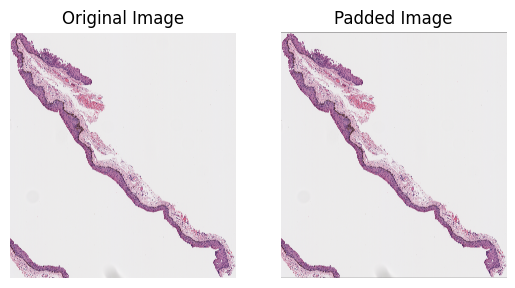

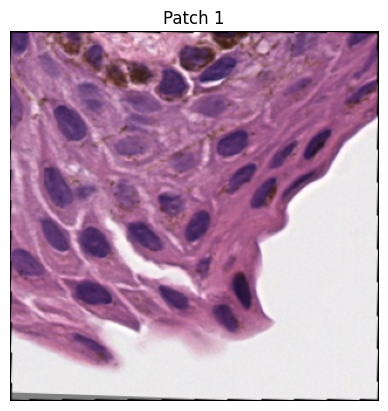

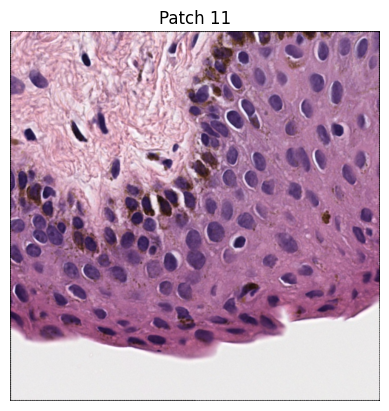

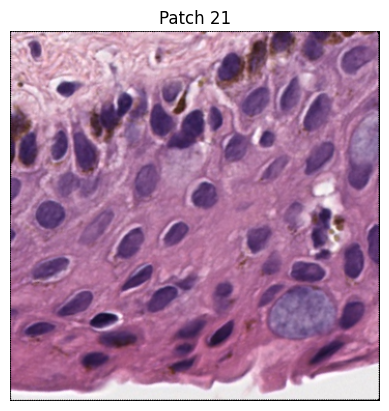

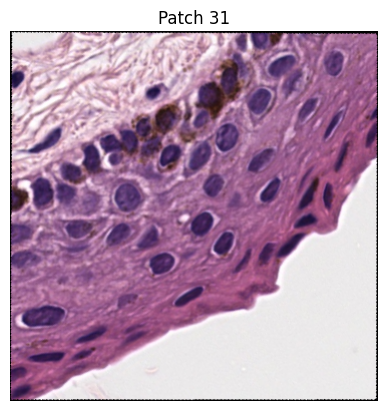

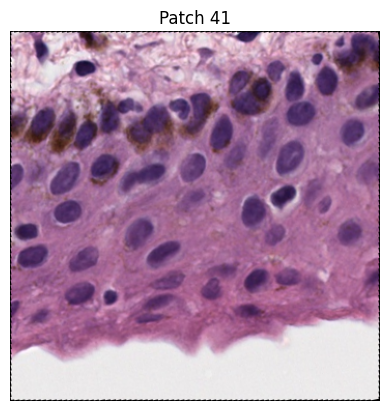

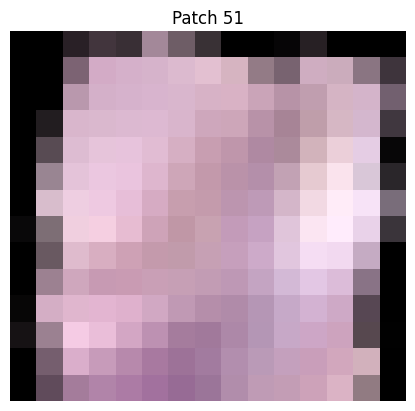

In [137]:
slice_name = 'testing_slices/h&e_benign_case25_match1_mask.png'
slice_details = 'testing_slices/h2114178 h&e_ROI_8.tif'

metrics, patched_images = patching_export(slice_name, slice_details)